<a href="https://colab.research.google.com/github/alsadh/Hydrogel-Gelation-Behavior-Porosity-Analysis/blob/main/SEM_segmentation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## How-To

To run this, either do "Runtime"->"Run all" or you can run each block of code one by one. Errors can likely be fixed by changing file paths.

In [8]:
import cv2
import numpy as np
from skimage.measure import label, regionprops
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage
import pandas as pd
from pathlib import Path
from google.colab import drive
from skimage.morphology import extrema
import matplotlib.pyplot as plt
from skimage.morphology import extrema
drive.mount('/content/drive') # this line connects this code to your google drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# This python code identifies pores in gels for the Bethany Almeida lab at
# Clarkson University. It also segments the pores (separates them) and then
# saves the average statistics for the pores.

# This block of code identifies and segments the pores
# modify this if you want to change how the pores are being classified


def segment_pores(image_path, h=6):
    # choose higher values of h to merge pores more aggressively
    # read image and remove bottom 70 pixels
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYßSCALE)
    img = img[:-70, :]

    # perform CLAHE which increases the contrast of image
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(16, 16))
    img_clahe = clahe.apply(img)

    # Finds the cutoff brightness value for dark region to be a pore
    binary = cv2.adaptiveThreshold(
        img_clahe, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=501, # the cutoff is calculated locally, this is the
        # pixel area used to find the cutoff
        C=7 # Higher value means pores must be darker to be classified
    )

    # finds the pore mask (black/white). black = no pore, white = pore
    pore_mask = cv2.bitwise_not(binary)
    kernel = np.ones((3,3), np.uint8)
    pore_mask = cv2.morphologyEx(pore_mask, cv2.MORPH_OPEN, kernel)
    pore_mask = pore_mask > 0

    # watershed, this combines pores/separates pores that should be seprated
    distance = ndimage.distance_transform_edt(pore_mask)
    distance_smooth = ndimage.gaussian_filter(distance, sigma=3)
    # higher sigma (above line) merges/blurs pores more
    h_max = extrema.h_maxima(distance_smooth, h=h)
    markers = label(h_max)
    segmented = watershed(-distance_smooth, markers, mask=pore_mask)

    props = regionprops(segmented)
    total_pixels = img.shape[0] * img.shape[1]

    areas, circularities, eccentricities = [], [], []
    for p in props:
        area = p.area
        perim = p.perimeter
        circularity = (4 * np.pi * area / perim**2) if perim > 0 else 0
        areas.append(area)
        circularities.append(circularity)
        eccentricities.append(p.eccentricity)

    porosity = pore_mask.sum() / total_pixels

    record = {
        "image": Path(image_path).name,
        "pore_count": len(props),
        "avg_area_micrometer": (np.mean(areas)*((100/267) ** 2)) if areas else 0, # 267 pixels = 100 micrometers
        "avg_circularity": np.mean(circularities) if circularities else 0,
        "avg_eccentricity": np.mean(eccentricities) if eccentricities else 0,
        "porosity": porosity,
    }

    return record

In [ ]:
# This block of code saves the pngs for the average statistics. It also saves
# the information for the excel file

STATS = ["avg_area_micrometer", "avg_circularity", "avg_eccentricity", "porosity"]

def save_boxplots(df, top_folder):
    named_folders = sorted(df["named_folder"].unique())
    colors = ["steelblue", "coral", "mediumseagreen"]

    for stat in STATS:
        fig, ax = plt.subplots(figsize=(8, 6))
        data = [df[df["named_folder"] == g][stat].dropna().values for g in named_folders]

        bp = ax.boxplot(data, tick_labels=named_folders, patch_artist=True,
                        medianprops=dict(color="black", linewidth=2))
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        for i, d in enumerate(data, start=1):
            ax.plot(i, d.mean(), marker="D", color="black", markersize=7,
                    zorder=5, label="Mean" if i == 1 else "")

        ax.set_title(f"{stat} by named folder")
        ax.set_ylabel(stat)
        ax.legend()
        plt.tight_layout()
        plt.savefig(top_folder / f"{stat}_boxplot.png", dpi=150)
        plt.close()

def save_excel(df, folder):
    named_folders = sorted(df["named_folder"].unique())
    out_path = Path(folder) / "summary_statistics.xlsx"

    with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
        for stat in STATS:
            rows = []
            for g in named_folders:
                vals = df[df["named_folder"] == g][stat].dropna()
                rows.append({
                    "named_folder": g,
                    "mean":   vals.mean(),
                    "median": vals.median(),
                    "std":    vals.std(),
                    "min":    vals.min(),
                    "max":    vals.max(),
                    "count":  len(vals),
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name=stat[:31], index=False)

    print(f"Saved summary_statistics.xlsx in {folder}")

In [ ]:
# this block of code defines how to process all the folders and subfolders
# if the organization of folders changes, change it here!

def batch_process(root_folder):
    # root_folder = Organized SEM data ....
    root_folder = Path(root_folder)
    all_records = []

    for top_folder in sorted(root_folder.iterdir()):
        # top_folder = GL-L-HE
        if not top_folder.is_dir():
            continue

        records = []

        for named_folder in sorted(top_folder.iterdir()):
            # named_folder = GL-L-HE (core)
            if not named_folder.is_dir():
                continue
            named_name = named_folder.name

            for subfolder in sorted(named_folder.iterdir()):
                # sub_folder = n1
                if not subfolder.is_dir():
                    continue

                for img_path in sorted(subfolder.glob("*.tif")):
                    record = segment_pores(img_path)
                    record["named_folder"] = named_name
                    record["subfolder"] = f"{named_name}/{subfolder.name}"
                    records.append(record)
                    print(f"{named_name}/{subfolder.name}/{img_path.name}: "
                          f"{record['pore_count']} pores, porosity={record['porosity']:.3f}")
        if records:
            df = pd.DataFrame(records)
            df.to_csv(top_folder / "image_stats.csv", index=False)
            save_boxplots(df, top_folder)
            save_excel(df, top_folder)

        all_records.extend(records)


# run the next line to perform the analysis. Change the path if there is an error. To find the path
# look at the "files" tab and navigate to your google drive and the SEM data folder.
# then right click to copy path

batch_process("/content/drive/MyDrive/Organized SEM data for analysis")

GL-L-HE (core)/n1/n1 1.tif: 91 pores, porosity=0.418
GL-L-HE (core)/n1/n1 2.tif: 104 pores, porosity=0.431
GL-L-HE (core)/n1/n1 3.tif: 126 pores, porosity=0.417
GL-L-HE (core)/n1/n1 4.tif: 109 pores, porosity=0.428
GL-L-HE (core)/n1/n1 5.tif: 125 pores, porosity=0.461
GL-L-HE (core)/n1/n1 6.tif: 115 pores, porosity=0.463
GL-L-HE (core)/n2/n2 1.tif: 113 pores, porosity=0.432
GL-L-HE (core)/n2/n2 2.tif: 100 pores, porosity=0.412
GL-L-HE (core)/n2/n2 3.tif: 125 pores, porosity=0.452
GL-L-HE (core)/n2/n2 4.tif: 106 pores, porosity=0.428
GL-L-HE (core)/n2/n2 5.tif: 112 pores, porosity=0.438
GL-L-HE (core)/n3/n3 1.tif: 108 pores, porosity=0.420
GL-L-HE (core)/n3/n3 2.tif: 109 pores, porosity=0.424
GL-L-HE (core)/n3/n3 3.tif: 96 pores, porosity=0.427
GL-L-HE (core)/n3/n3 4.tif: 121 pores, porosity=0.459
GL-L-HE (core)/n3/n3 5.tif: 122 pores, porosity=0.466
GL-L-HE (core)/n3/n3 6.tif: 134 pores, porosity=0.425
GL-L-HE (core)/n3/n3 7.tif: 118 pores, porosity=0.440
GL-L-HE (mold)/n1/n1 1.tif: 14

## Individual Image Analysis

The following two lines of code allow you to create visalizations for any image of your choosing. Just find the path of the image you want to analyze and copy it below.

In [9]:
def visualize_segmentation(image_path, h=6):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    img = img[:-70, :]

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(16, 16))
    img_clahe = clahe.apply(img)

    binary = cv2.adaptiveThreshold(
        img_clahe, 255, # replace with img to not use CLAHE
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=501,  # tune: larger than biggest pore diameter in pixels
        C=7            # tune: how much darker than local mean = pore
    )

    pore_mask = cv2.bitwise_not(binary)
    kernel = np.ones((3,3), np.uint8)
    pore_mask = cv2.morphologyEx(pore_mask, cv2.MORPH_OPEN, kernel)
    pore_mask = pore_mask > 0

    distance = ndimage.distance_transform_edt(pore_mask)
    distance_smooth = ndimage.gaussian_filter(distance, sigma=3)

    # watershed
    h_max = extrema.h_maxima(distance_smooth, h=h)
    markers = label(h_max)
    segmented = watershed(-distance_smooth, markers, mask=pore_mask)
    #segmented = label(pore_mask) # no watershed

    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay = img_rgb.copy()

    # Draw each pore as a transparent colored region
    np.random.seed(42)
    for region_id in np.unique(segmented):
        if region_id == 0:
            continue
        color = np.random.randint(50, 255, 3)
        overlay[segmented == region_id] = (
            0.5 * img_rgb[segmented == region_id] + 0.5 * color
        ).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title("Original")
    axes[1].imshow(pore_mask, cmap='gray')
    axes[1].set_title(f"Pore mask (threshold=local)")
    axes[2].imshow(overlay)
    axes[2].set_title(f"Segmented pores (n={segmented.max()})")

    props = regionprops(segmented)
    for p in props:
        y, x = p.centroid
        axes[2].text(x, y, str(p.label), color='white', fontsize=6,
                     ha='center', va='center')

    plt.tight_layout()
    plt.savefig("segmentation_check.png", dpi=150)
    plt.show()

# aspect ratio, oval fitting (elongated)

#visualize_segmentation("/content/drive/MyDrive/SEM_Segmentation26/SI-S-LE (core) n1_4.tif")
#visualize_segmentation("/content/drive/MyDrive/SEM_Segmentation26/SI-S-LE (mold) n3_1.tif")

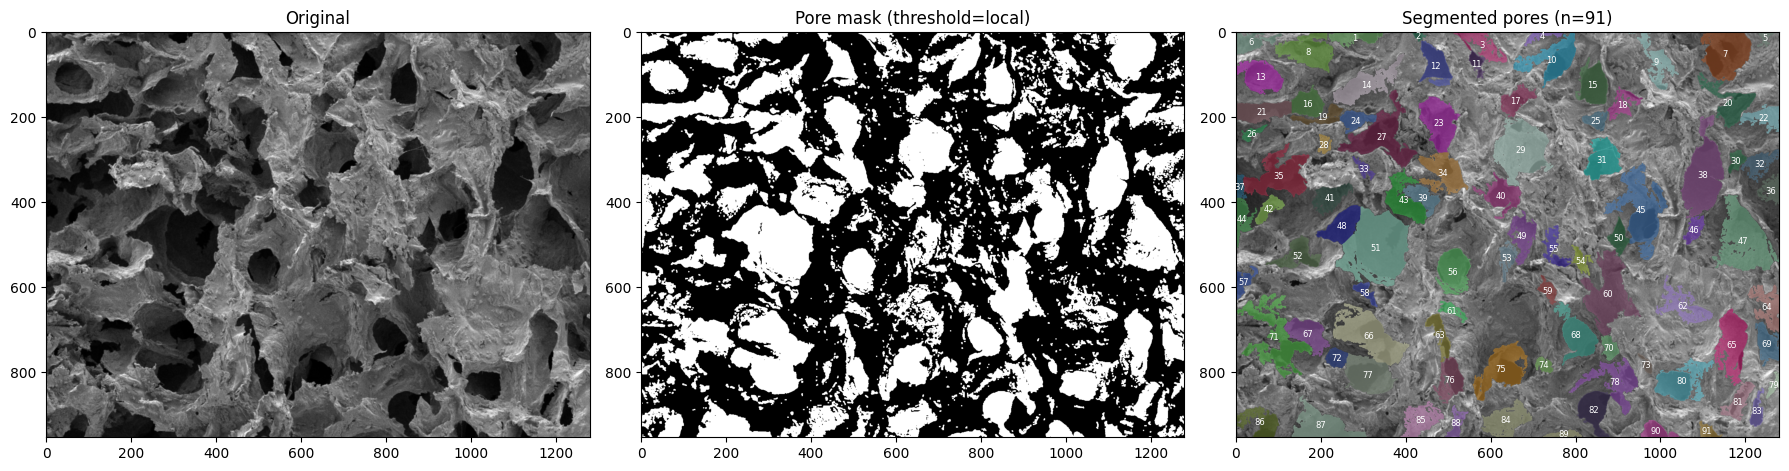

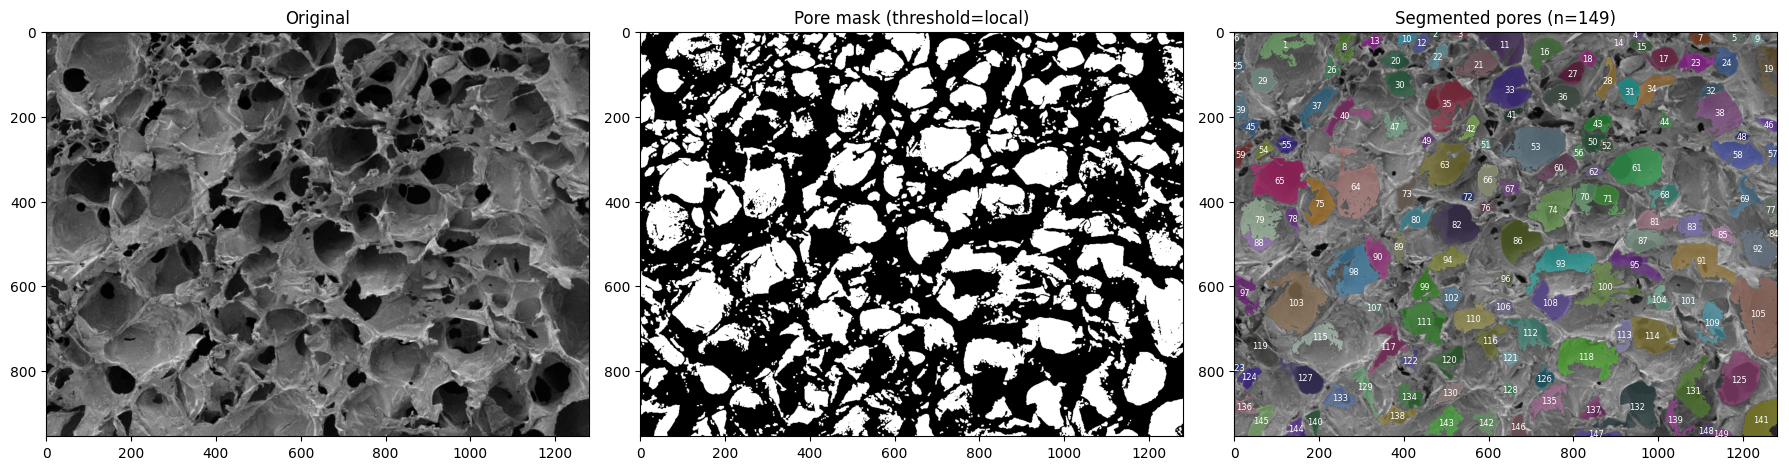

In [11]:
visualize_segmentation("/content/drive/MyDrive/Organized SEM data for analysis/GL-L-HE/GL-L-HE (core)/n1/n1 1.tif")
visualize_segmentation("/content/drive/MyDrive/Organized SEM data for analysis/GL-L-HE/GL-L-HE (mold)/n1/n1 1.tif")